<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

# Onderzoek naar CO₂-Uitstoot

**Auteurs:** Lucas Hoetink, Lucas van Hamersveld, Robin Djerahian

**Datum:** 30 mei 2026

<br>

---

## Samenvatting

In dit onderzoek onderzoeken wij welke persoonlijke en mobiliteitsgebonden factoren de jaarlijkse CO₂-uitstoot van individuen verklaren. Wij analyseren een dataset van 1500 burgers met behulp van beschrijvende statistieken, correlatie- en regressieanalyse, kansrekening, visualisatie en een statistische toets.

<br>

---

## Inhoudsopgave

1. [Inleiding & Onderzoeksvraag](#Inleiding-&-Onderzoeksvraag)
2. [Hypothese](#Hypothese)
3. [Beschrijvende Statistieken](#Beschrijvende-Statistieken)
4. [Visualisatie van de Dataset](#Visualisatie-van-de-Dataset)
5. [Preparatie van de Dataset](#Preparatie-van-de-Dataset)
6. [Kansrekening](#Kansrekening)
7. [Statistische Toets](#Statistische-Toets)
8. [Lineaire Regressie](#Lineaire-Regressie)
9. [Logistische Regressie](#Logistische-Regressie)
10. [Conclusie](#Conclusie)

<br>

---

</div>

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

# Inleiding & Onderzoeksvraag

Het mobiliteitsgedrag van burgers speelt een sleutelrol bij de uitstoot van broeikasgassen en het behalen van de nationale klimaatdoelstellingen. In dit onderzoek stellen wij de volgende vraagstellingen centraal:

- *Welke persoonlijke en mobiliteitsgebonden factoren verklaren verschillen in de jaarlijkse CO₂-uitstoot tussen burgers?*
- *In welke mate kunnen wij de individuele uitstoot nauwkeurig voorspellen op basis van een combinatie van sociaaldemografische kenmerken en mobiliteitsgedrag?*

<br>

---

</div>

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

# Voorbereiding van het notebook

<br>

</div>

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

df = pd.read_excel('https://github.com/EchoinSilences/WiskundePortfolioHHS/raw/main/Mobiliteitsdata.xlsx')

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Beschrijvende Statistieken

In dit hoofdstuk berekenen en interpreteren wij de belangrijkste beschrijvende statistieken van de dataset, zowel handmatig als in Python. Denk hierbij aan het gemiddelde, de mediaan, de modus, de standaardafwijking en het bereik van de relevante variabelen.

</div>

In [3]:
# Python: Bepaal voor elke kolom de relevante beschrijvende statistieken

numeric_cols = df.select_dtypes(include='number').columns
data = []

for col in numeric_cols:
    col_data = df[col]
    data.append({
        'kolom':      col,
        'gemiddelde': col_data.mean(),
        'mediaan':    col_data.median(),
        'modus':      col_data.mode()[0],
        'std':        col_data.std(),
        'minimum':    col_data.min(),
        'maximum':    col_data.max(),
    })

describing_df = pd.DataFrame(data).set_index('kolom')
display(describing_df.round(2))

,gemiddelde,mediaan,modus,std,minimum,maximum
kolom,,,,,,
persoon_ID,560229.09,563847.00,177895.00,260939.29,102295.00,999493.00
leeftijd,47.99,47.00,20.00,18.13,0.00,79.00
gewicht_KG,75.15,75.79,76.29,14.80,0.00,117.76
jaarsalaris_eu,40092.55,40503.08,-8505.15,14986.84,-8505.15,93826.85
huishouden_grootte,3.03,3.00,3.00,1.41,1.00,5.00
km_auto_per_jaar,8597.26,9356.38,0.00,7021.43,-6506.63,34618.87
km_fiets_per_jaar,1794.18,1910.00,0.00,753.99,0.00,3672.70
km_ov_per_jaar,2942.22,2987.03,2159.08,1531.38,-2264.78,8018.06
km_vliegtuig_per_jaar,1072.28,1052.14,0.00,748.65,0.00,3808.20


In [4]:
# Python: Ga na of er missende/niet kloppende/extreme waarden zijn in de dataset
# en ga hier op een adequate manier mee om.

# ── 1. MISSENDE WAARDEN ───────────────────────────────────────────────────────
print("=== Missende waarden per kolom ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Numerieke kolommen: imputeer met de mediaan (robuust tegen uitschieters)
# Categoriale kolommen: imputeer met de modus
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissende waarden na imputatie:", df.isnull().sum().sum())

# ── 2. NIET-KLOPPENDE WAARDEN (negatieve waarden) ────────────────────────────
# Kolommen waarbij een negatieve waarde logisch onmogelijk is
niet_negatief = [
    'jaarsalaris_eu', 'km_auto_per_jaar', 'km_fiets_per_jaar',
    'km_ov_per_jaar', 'km_vliegtuig_per_jaar', 'dagen_in_buitenland_per_jaar',
    'co2_uitstoot_per_jaar_KG', 'leeftijd', 'gewicht_KG', 'huishouden_grootte'
]

print("\n=== Negatieve waarden per kolom ===")
for col in niet_negatief:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print(f"  {col}: {n_neg} negatieve waarde(n)")

# Negatieve waarden vervangen door de mediaan van de kolom
for col in niet_negatief:
    mediaan = df.loc[df[col] >= 0, col].median()
    df.loc[df[col] < 0, col] = mediaan

print("Negatieve waarden gecorrigeerd.")

print("\nDataset na opschoning:", df.shape)
df.describe().round(2)

=== Missende waarden per kolom ===
jaarsalaris_eu              1
stad                        1
opleiding_niveau            1
autobezit                   1
co2_uitstoot_per_jaar_KG    7
dtype: int64

Missende waarden na imputatie: 0

=== Negatieve waarden per kolom ===
  jaarsalaris_eu: 7 negatieve waarde(n)
  km_auto_per_jaar: 12 negatieve waarde(n)
  km_ov_per_jaar: 41 negatieve waarde(n)
Negatieve waarden gecorrigeerd.

Dataset na opschoning: (1500, 22)


,persoon_ID,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,dagen_in_buitenland_per_jaar,co2_uitstoot_per_jaar_KG
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00
mean,560229.09,47.99,75.15,40303.87,3.03,8685.77,1794.18,3042.00,1072.28,2.53,2.47,14.49,4911.24
std,260939.29,18.13,14.80,14664.02,1.41,6959.66,753.99,1409.22,748.65,1.67,1.67,8.70,3414.94
min,102295.00,0.00,0.00,294.11,1.00,0.00,0.00,3.06,0.00,0.00,0.00,0.00,0.00
25%,332525.75,32.00,65.64,30188.84,2.00,0.00,1503.42,2069.28,471.54,1.00,1.00,7.00,1471.52
50%,563847.00,47.00,75.79,40576.27,3.00,9433.98,1910.00,3058.34,1052.14,3.00,2.00,15.00,4677.28
75%,792686.75,64.00,84.94,50280.61,4.00,13842.73,2286.18,3991.54,1588.56,4.00,4.00,22.00,7471.17
max,999493.00,79.00,117.76,93826.85,5.00,34618.87,3672.70,8018.06,3808.20,5.00,5.00,29.00,18098.44


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Visualisatie van de Dataset

In dit hoofdstuk visualiseren wij de verdeling van de dataset in Python en interpreteren wij de grafieken. Wij maken gebruik van geschikte diagrammen om de CO₂-uitstoot en de belangrijkste verklarende variabelen inzichtelijk te maken.

</div>

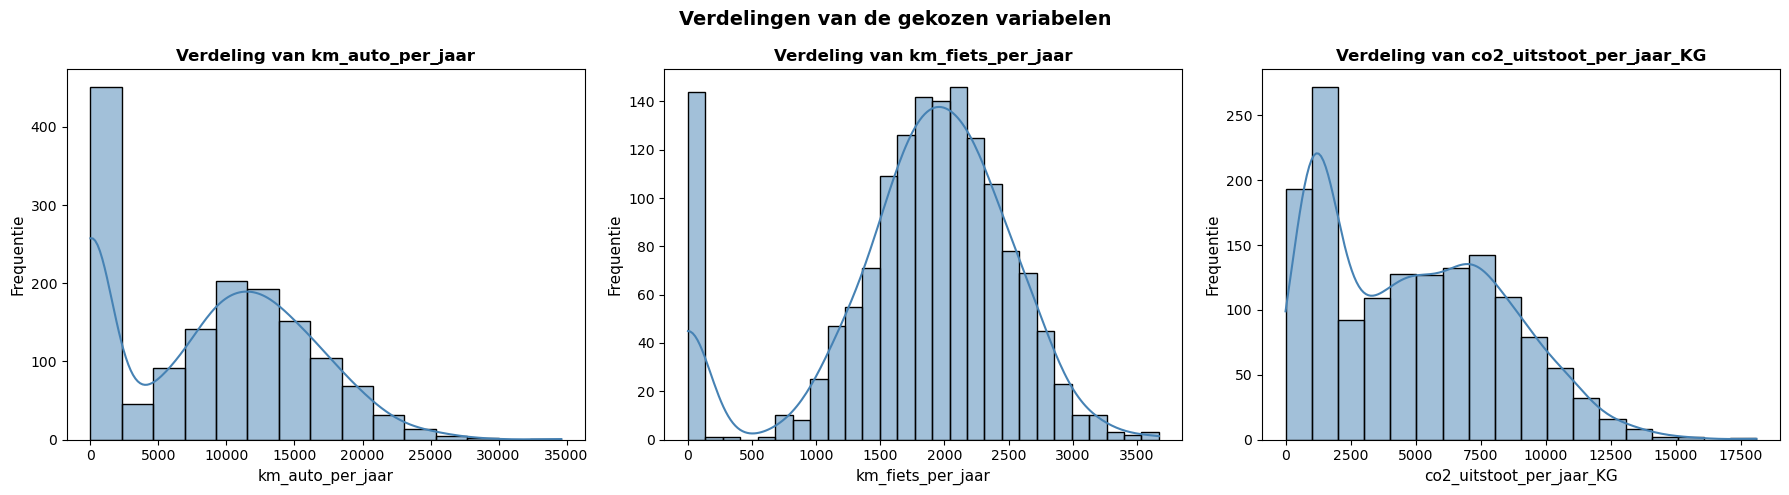

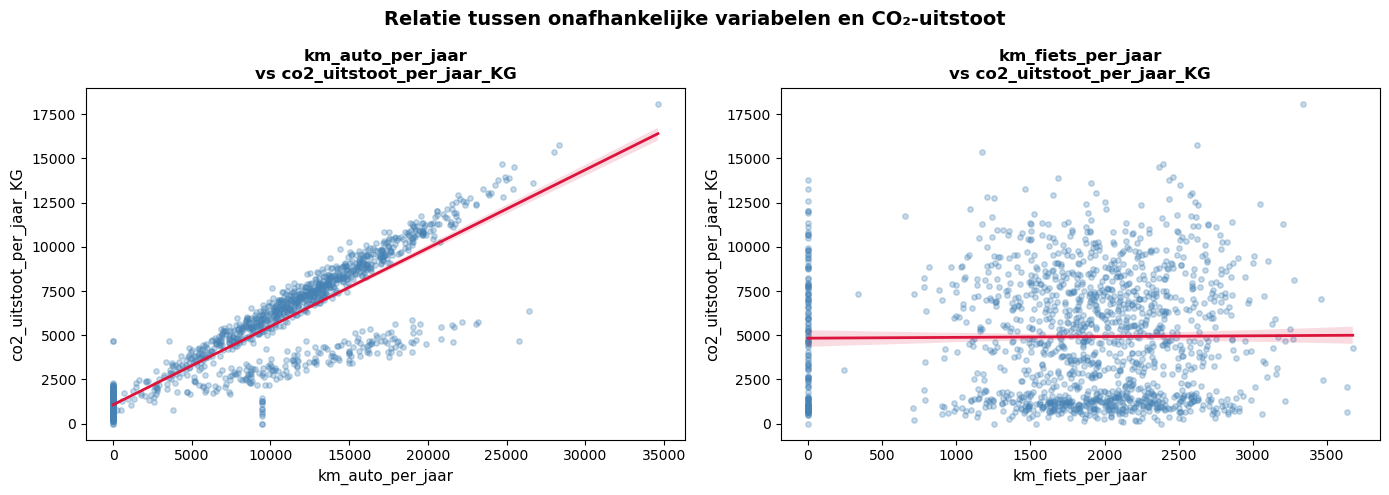

In [5]:
# Python: Kies 2 onafhankelijke variabelen waarvan je denkt dat het invloed kan hebben
# op de jaarlijkse CO2-uitstoot. Visualiseer de verdeling van deze twee variabelen
# en de verdeling van de afhankelijke variabele (CO2-uitstoot).
# Wij kiezen km_auto_per_jaar en km_fiets_per_jaar tegenover co2_uitstoot_per_jaar_KG.

gekozen_vars = ['km_auto_per_jaar', 'km_fiets_per_jaar']
target = 'co2_uitstoot_per_jaar_KG'
alle_vars = gekozen_vars + [target]

# ── Histogrammen ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var in zip(axes, alle_vars):
    sns.histplot(df[var], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Verdeling van {var}', fontsize=12, fontweight='bold')
    ax.set_xlabel(var, fontsize=11)
    ax.set_ylabel('Frequentie', fontsize=11)

plt.suptitle('Verdelingen van de gekozen variabelen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Regplots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, var in zip(axes, gekozen_vars):
    sns.regplot(data=df, x=var, y=target, ax=ax,
                scatter_kws={'alpha': 0.3, 's': 15, 'color': 'steelblue'},
                line_kws={'color': 'crimson', 'linewidth': 2})
    ax.set_xlabel(var, fontsize=11)
    ax.set_ylabel(target, fontsize=11)
    ax.set_title(f'{var}\nvs {target}', fontsize=12, fontweight='bold')

plt.suptitle('Relatie tussen onafhankelijke variabelen en CO₂-uitstoot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Python: Toets, met behulp van statistiek, of de verdelingen normaal verdeeld zijn.
# Shapiro-Wilk toets voor alle numerieke kolommen (max 500 rijen vanwege gevoeligheid bij grote datasets)

resultaten = []
for col in gekozen_vars + [target]:
    stat, p = stats.shapiro(df[col])
    resultaten.append({
        'kolom': col,
        'Shapiro-W': round(stat, 4),
        'p-waarde': round(p, 4),
        'Normaal verdeeld': 'Ja' if p > 0.05 else 'Nee'
    })

shapiro_df = pd.DataFrame(resultaten).set_index('kolom')
display(shapiro_df)

,Shapiro-W,p-waarde,Normaal verdeeld
kolom,,,
km_auto_per_jaar,0.9154,0.0,Nee
km_fiets_per_jaar,0.9072,0.0,Nee
co2_uitstoot_per_jaar_KG,0.9398,0.0,Nee


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Preparatie van de Dataset

In dit hoofdstuk transformeren wij de data zodat deze in machine-learning gebruikt kan worden


</div>

In [11]:
# Python: Voer de transformatie uit.
# Let op dat je de getransformeerde variabelen in een nieuw dataframe opslaat,
# zodat je de oorspronkelijke waarden behoudt.

from sklearn.preprocessing import StandardScaler

# ── Variabelen per meetniveau ─────────────────────────────────────────────────
nominaal = ['geslacht', 'burgerlijke_staat', 'stad', 'provincie',
            'autobezit', 'fietsbezit', 'elektrisch_auto', 'gebruik_carsharing']

ordinaal = ['opleiding_niveau']

ratio = ['leeftijd', 'gewicht_KG', 'jaarsalaris_eu', 'huishouden_grootte',
         'km_auto_per_jaar', 'km_fiets_per_jaar', 'km_ov_per_jaar',
         'km_vliegtuig_per_jaar', 'dagen_thuiswerken_per_week_pro_rato',
         'dagen_kantoorwerken_per_week_pro_rato', 'dagen_in_buitenland_per_jaar']

target = 'co2_uitstoot_per_jaar_KG'

# ── 1. One-hot encoding voor nominale variabelen ──────────────────────────────
df_ohe = pd.get_dummies(df[nominaal], drop_first=False).astype(int)

# ── 2. Ordinal encoding voor opleiding_niveau ─────────────────────────────────
opleiding_volgorde = {
    'geen': 0, 'basisonderwijs': 1, 'vmbo': 2, 'mbo': 3,
    'havo_vwo': 4, 'hbo': 5, 'wo': 6
}
df_ord = df[ordinaal].copy()
df_ord['opleiding_niveau'] = df_ord['opleiding_niveau'].str.lower().map(opleiding_volgorde)
# Onbekende waarden opvangen
df_ord['opleiding_niveau'] = df_ord['opleiding_niveau'].fillna(df_ord['opleiding_niveau'].median()).astype(int)

# ── 3. Standaardisatie voor ratio-variabelen ──────────────────────────────────
scaler = StandardScaler()
df_ratio_scaled = pd.DataFrame(
    scaler.fit_transform(df[ratio]),
    columns=ratio,
    index=df.index
)

# ── 4. Alles samenvoegen in een nieuw dataframe ───────────────────────────────
df_transformed = pd.concat([df_ratio_scaled, df_ord, df_ohe, df[[target]]], axis=1)

print(f"Origineel dataframe:     {df.shape}")
print(f"Getransformeerd dataframe: {df_transformed.shape}")
display(df_transformed.head())

Origineel dataframe:     (1500, 22)
Getransformeerd dataframe: (1500, 69)


,leeftijd,gewicht_KG,jaarsalaris_eu,huishouden_grootte,km_auto_per_jaar,km_fiets_per_jaar,km_ov_per_jaar,km_vliegtuig_per_jaar,dagen_thuiswerken_per_week_pro_rato,dagen_kantoorwerken_per_week_pro_rato,...,fietsbezit_ja,fietsbezit_nee,elektrisch_auto_ja,elektrisch_auto_nee,gebruik_carsharing_Altijd,gebruik_carsharing_Heel soms,gebruik_carsharing_Nooit,gebruik_carsharing_Soms,gebruik_carsharing_Vaak,co2_uitstoot_per_jaar_KG
0,0.110910,-1.520186,0.525254,1.395203,0.658337,0.326850,0.131999,-0.790441,0.878218,-0.878218,...,1,0,0,1,0,0,1,0,0,7591.93
1,0.938319,-0.714335,1.016756,-0.731631,0.940606,-2.380371,-0.527443,0.469083,1.476731,-1.476731,...,0,1,0,1,0,1,0,0,0,8742.25
2,0.055749,1.063001,-0.734702,-0.731631,1.605134,-0.336615,1.037950,-0.587649,0.878218,-0.878218,...,1,0,1,0,1,0,0,0,0,4513.56
3,-0.771661,0.357205,0.283059,-0.731631,0.179627,0.042110,0.969343,0.259971,0.279705,-0.279705,...,1,0,0,1,0,1,0,0,0,6904.41
4,0.662516,-0.193776,1.104688,-0.731631,1.089625,0.075477,-0.785004,0.806683,-1.515833,1.515833,...,1,0,1,0,0,0,1,0,0,4420.80


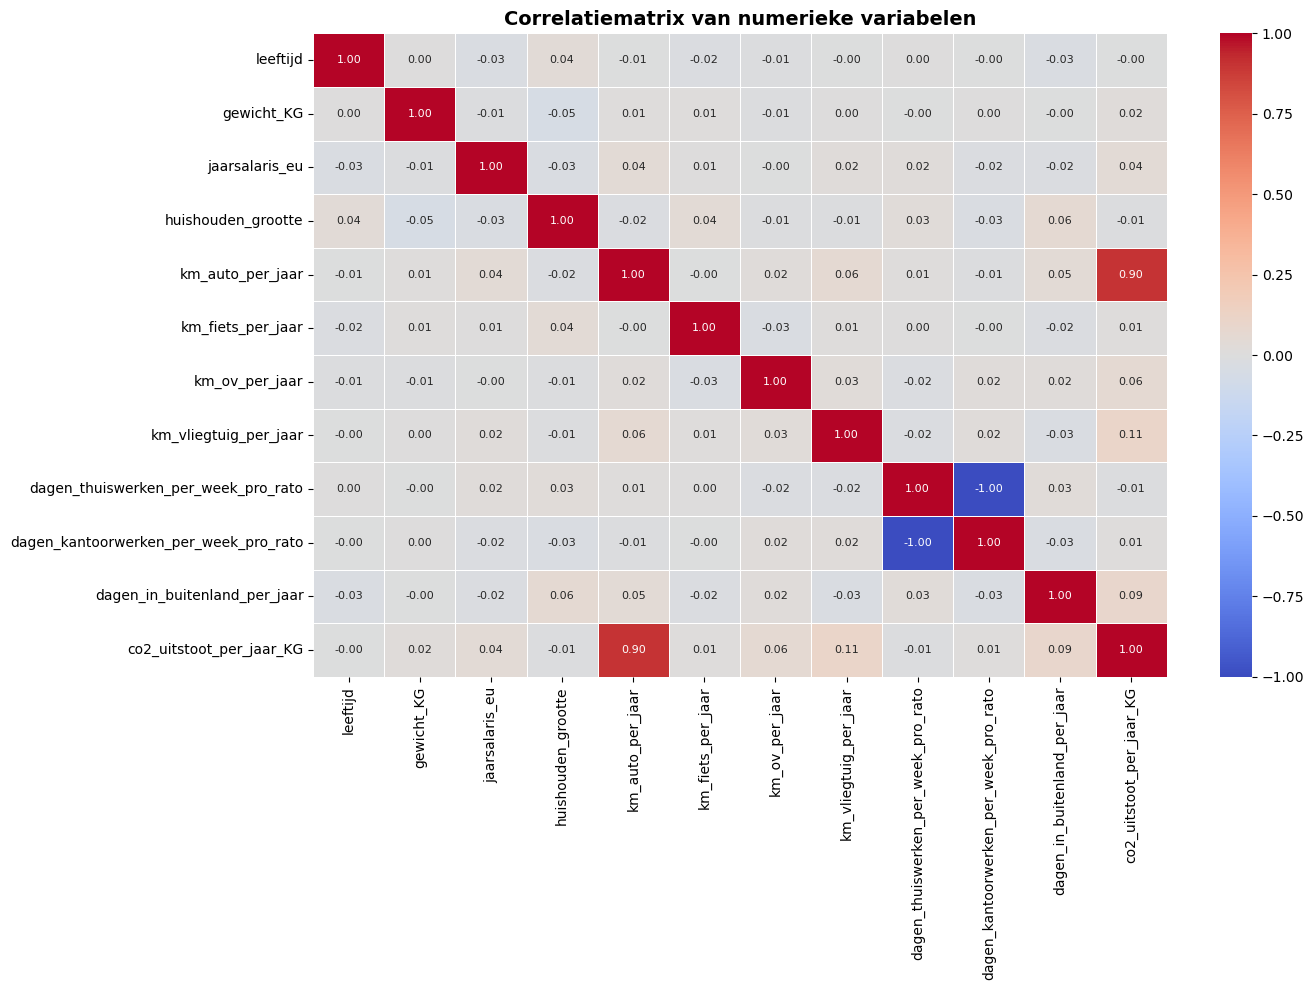


Correlaties met 'co2_uitstoot_per_jaar_KG' (gesorteerd):


,co2_uitstoot_per_jaar_KG
km_auto_per_jaar,0.903
km_vliegtuig_per_jaar,0.106
dagen_in_buitenland_per_jaar,0.087
km_ov_per_jaar,0.061
jaarsalaris_eu,0.043
gewicht_KG,0.016
dagen_kantoorwerken_per_week_pro_rato,0.013
km_fiets_per_jaar,0.010
leeftijd,-0.005
huishouden_grootte,-0.012


In [12]:
# Python: Zorg dat je inzicht krijgt in de relaties tussen alle variabelen.
# Correlatiematrix van alle ratio-variabelen + target

ratio_cols = ratio + [target]
corr_matrix = df[ratio_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Correlatiematrix van numerieke variabelen', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlaties met de target
print(f"\nCorrelaties met '{target}' (gesorteerd):")
display(corr_matrix[[target]].drop(target).sort_values(target, ascending=False).round(3))

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Kansrekening

In dit hoofdstuk passen wij de regels van kansrekening toe op de dataset. Wij berekenen kansen op basis van de gegevens van de 1500 burgers en interpreteren de uitkomsten.


</div>

In [19]:
# Wat is de kans dat een willekeurig persoon 5000 KG CO2 uitstoot?
# Gebruik de standaard normaal verdeling in de berekening.

grenswaarde = 5000

mu    = df[target].mean()
sigma = df[target].std()

# Standaardiseren: z = (x - mu) / sigma
z = (grenswaarde - mu) / sigma

kans_cdf = 1 - stats.norm.cdf(z)

print(f"Gemiddelde (mu):    {mu:.2f} KG")
print(f"Standaardafw. (s):  {sigma:.2f} KG")
print(f"Z-score:            {z:.4f}")
print(f"P(CO2 > {grenswaarde} KG) = 1 - Phi({z:.4f}) = {kans_cdf:.4f}  ({kans_cdf*100:.2f}%)")

Gemiddelde (mu):    4911.24 KG
Standaardafw. (s):  3414.94 KG
Z-score:            0.0260
P(CO2 > 5000 KG) = 1 - Phi(0.0260) = 0.4896  (48.96%)


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---


# Hypothese

Kies een categoriale variabele uit de dataset waarmee de dataset gescheiden kan worden in tenminste 2 groepen. Je mag niet geslacht kiezen. Je gaat onderzoek doen of er een verschil zit in de uitstoot van CO2 tussen de groepen die je hebt gekozen.

Op basis van onze verwachtingen en algemene kennis over mobiliteitsgedrag formuleren wij de volgende hypothesen:
- Het hebben van een fiets maakt niets uit voor de jaarlijkse CO2 uitstoot
- Het hebben van een fiets maakt statistisch significant uit voor de jaarlijkse CO2 uitstoot

<br>

</div>

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Statistische Toets

In dit hoofdstuk kiezen wij een geschikte statistische toets op basis van de onderzoeksvraag en de aard van de data. Wij voeren de toets uit in Python en interpreteren de resultaten, inclusief de p-waarde en de conclusie ten aanzien van de hypothese.

</div>

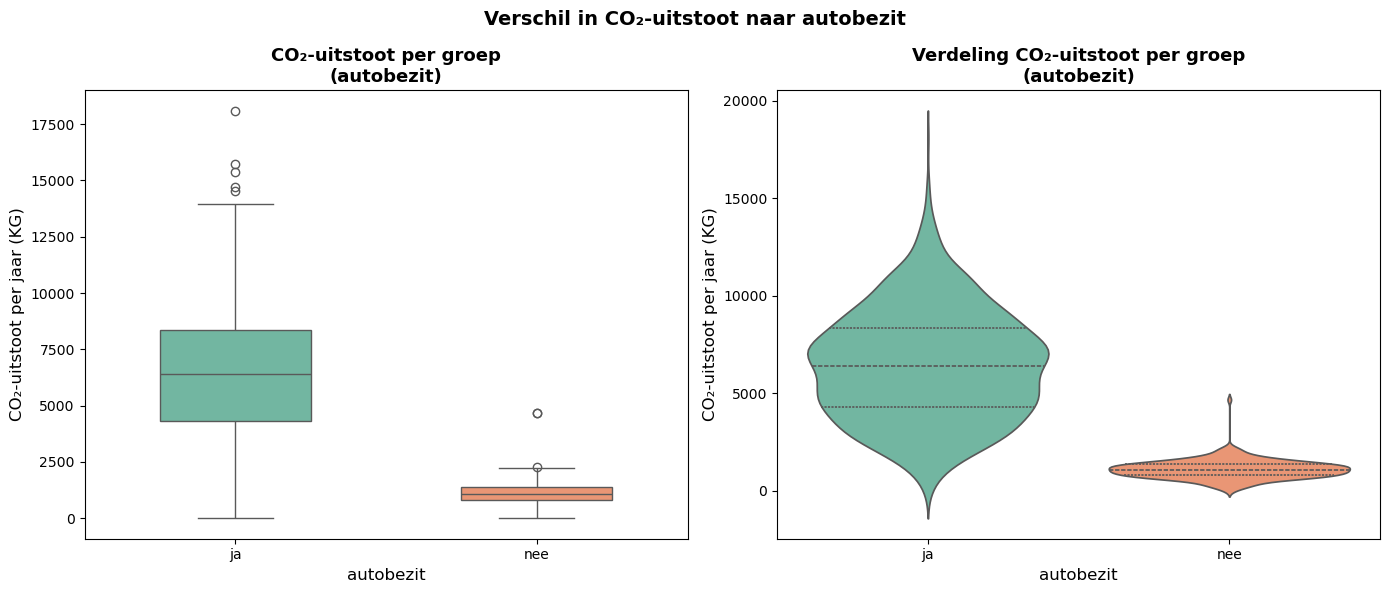

Gemiddelde CO₂-uitstoot per groep:


,mean,median,std,count
autobezit,,,,
ja,6454.22,6414.31,2836.57,1067
nee,1109.04,1076.22,490.22,433


In [24]:
# Python: Maak de geschikte plotjes om het verschil tussen de groepen te visualiseren.
# Groepsvariabele: fietsbezit | Afhankelijke variabele: co2_uitstoot_per_jaar_KG

groep_var = 'autobezit'
groepen   = df[groep_var].unique()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Boxplot ───────────────────────────────────────────────────────────────────
sns.boxplot(data=df, x=groep_var, y=target, hue=groep_var, legend=False,
            ax=axes[0], palette='Set2', width=0.5)
axes[0].set_title(f'CO₂-uitstoot per groep\n({groep_var})', fontsize=13, fontweight='bold')
axes[0].set_xlabel(groep_var, fontsize=12)
axes[0].set_ylabel('CO₂-uitstoot per jaar (KG)', fontsize=12)

# ── Violin plot ───────────────────────────────────────────────────────────────
sns.violinplot(data=df, x=groep_var, y=target, hue=groep_var, legend=False,
               ax=axes[1], palette='Set2', inner='quartile')
axes[1].set_title(f'Verdeling CO₂-uitstoot per groep\n({groep_var})', fontsize=13, fontweight='bold')
axes[1].set_xlabel(groep_var, fontsize=12)
axes[1].set_ylabel('CO₂-uitstoot per jaar (KG)', fontsize=12)

plt.suptitle(f'Verschil in CO₂-uitstoot naar {groep_var}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Gemiddelde per groep
print("Gemiddelde CO₂-uitstoot per groep:")
display(df.groupby(groep_var)[target].agg(['mean', 'median', 'std', 'count']).round(2))

In [27]:
# Python: Voer de statistische toets uit.
# Omdat de verdelingen niet normaal zijn (zie Shapiro-Wilk), gebruiken wij
# de Mann-Whitney U toets (niet-parametrisch alternatief voor de t-toets).
#
# H0: Er is geen verschil in CO₂-uitstoot tussen de fietsbezit-groepen
# H1: Er is een statistisch significant verschil in CO₂-uitstoot tussen de fietsbezit-groepen
# Significantieniveau: alpha = 0.05

alpha = 0.05

groepen = df[groep_var].unique()
print(f"Groepen in '{groep_var}': {groepen}\n")

# Splits in twee groepen
groep_waarden = [df.loc[df[groep_var] == g, target].values for g in groepen]

# Mann-Whitney U toets
u_stat, p_waarde = stats.mannwhitneyu(*groep_waarden, alternative='two-sided')

print("Mann-Whitney U toets")
print(f"U-statistiek: {u_stat:.2f}")
print(f"p-waarde:     {p_waarde:.4f}")
print()
if p_waarde < alpha:
    print(f"Conclusie: p = {p_waarde:.4f} < alpha = {alpha}")
    print("→ H0 verworpen: er is een statistisch significant verschil in CO₂-uitstoot")
    print(f"  tussen personen met en zonder {groep_var}.")
else:
    print(f"Conclusie: p = {p_waarde:.4f} >= alpha = {alpha}")
    print("→ H0 niet verworpen: er is geen statistisch significant verschil in CO₂-uitstoot")
    print(f"  tussen personen met en zonder {groep_var}.")

Groepen in 'autobezit': ['ja' 'nee']

Mann-Whitney U toets
U-statistiek: 455357.00
p-waarde:     0.0000

Conclusie: p = 0.0000 < alpha = 0.05
→ H0 verworpen: er is een statistisch significant verschil in CO₂-uitstoot
  tussen personen met en zonder autobezit.


<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Lineaire Regressie

In dit hoofdstuk bouwen wij een lineair regressiemodel om de jaarlijkse CO₂-uitstoot te voorspellen. Wij splitsen de data in een train- en testset, trainen het model, bepalen de meest invloedrijke variabelen en vergelijken twee modellen met behulp van 20-fold cross-validatie en een statistische toets.

</div>

In [ ]:
# Python: Split de data op in een train- en testset. Kies zelf voor een geschikte split.

In [ ]:
# Python: Train een lineair regressiemodel om de jaarlijkse CO₂-uitstoot te voorspellen.

In [ ]:
# Python: Bepaal welke 5 onafhankelijke variabelen de meeste invloed hebben op de voorspelling.

In [ ]:
# Python: Train en test nu twee modellen:
# Model 1: met alle variabelen
# Model 2: met de vijf meest invloedrijke variabelen
# Gebruik hiervoor 20-fold cross-validatie.

In [ ]:
# Python: Gebruik de gekozen metric om de nauwkeurigheid van beide modellen te kwantificeren.

In [ ]:
# Python: Maak de geschikte plotjes om het verschil in nauwkeurigheid tussen de twee modellen te visualiseren.

In [ ]:
# Python: Gebruik toetsende statistiek en de resultaten van de 20-fold cross-validatie
# om te onderzoeken welk model significant beter is.

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Logistische Regressie

In dit hoofdstuk zetten wij de CO₂-uitstoot om naar een binaire klasse (lage vs. hoge uitstoot) en trainen wij een logistisch regressiemodel op de vijf meest invloedrijke variabelen.

</div>

In [ ]:
# Python: Splits de target variabele op in 2 klassen van gelijke grootte.
# Kies hiervoor een geschikte afkapwaarde.
# Codeer de eerste groep als 0 (lage uitstoot) en de tweede groep als 1 (hoge uitstoot).

In [ ]:
# Python: Train een nieuw model op de nieuwe target.
# Gebruik hierbij alleen de vijf meest invloedrijke onafhankelijke variabelen die je eerder hebt gekozen.

<div style="font-family: 'Times New Roman', serif; line-height: 1.3;">

---

# Conclusie

In dit hoofdstuk geven wij antwoord op de onderzoeksvraag op basis van de resultaten uit de vorige hoofdstukken. Wij bespreken in hoeverre onze hypothesen bevestigd of verworpen zijn en wat de bevindingen betekenen in de bredere context van CO₂-uitstoot en mobiliteitsgedrag.

</div>